# 文献约束的单液滴电场模型

## tl;dr
下面直接计算同净电荷球壳/体电荷、严格中性双电层与有限厚度偶极层的径向电场。文献数值与适用环境见 `../data/literature_parameters.csv`。

## Context & Methods

以半径 50 μm 的水滴为基准；局域探针场与远程 Coulomb 场分别参数化。参考 [JCP 2020](https://doi.org/10.1063/5.0006550)、[JPCL 2020](https://doi.org/10.1021/acs.jpclett.0c02061)、[Nature Communications 2022](https://doi.org/10.1038/s41467-021-27941-x) 和 [2024](https://doi.org/10.1038/s41467-024-47879-0)。

In [1]:
# 所有 Notebook 都从项目根目录读取配置和写入 results/。
from pathlib import Path
import sys
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
# 不要求先 pip install；优先直接导入当前工作树中的源码。
sys.path.insert(0, str(ROOT / 'src'))
import droplet_shadow
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams.update({'figure.figsize': (7, 4), 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})

In [2]:
# 创建基准几何，只把净电荷改为 10^7 e；M 是几何放大率。
from droplet_shadow import SimulationConfig, build_field
from droplet_shadow.fields import rayleigh_charge_e
from droplet_shadow.config import Charge
base = SimulationConfig().with_updates(charge={'q_e': 1e7})
print(f'M={base.geometry.magnification:.1f}, Q/Q_R={1e7/rayleigh_charge_e(base.geometry.radius_m, 0.072):.3f}')

M=51.0, Q/Q_R=0.226


## Results

### 同净电荷分布的内外场

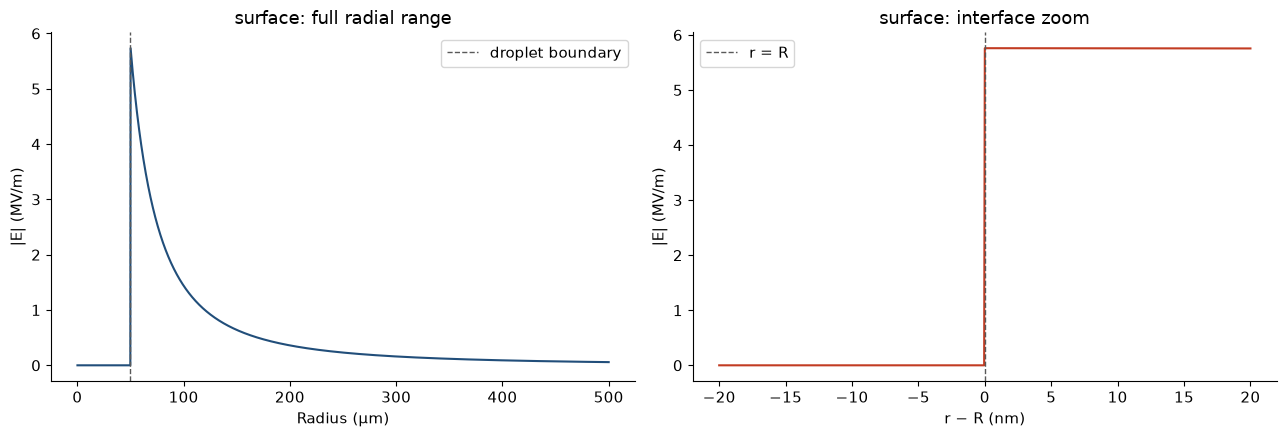

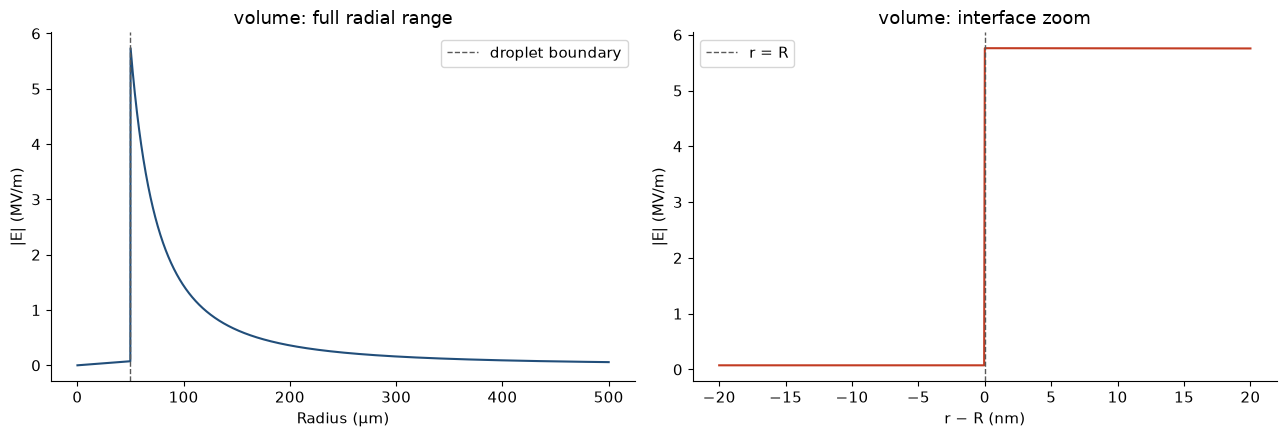

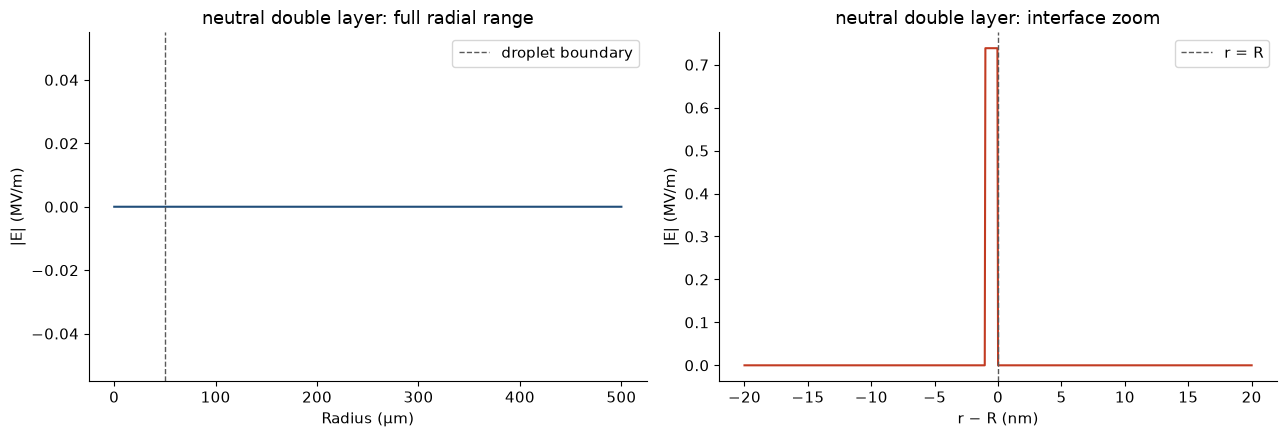

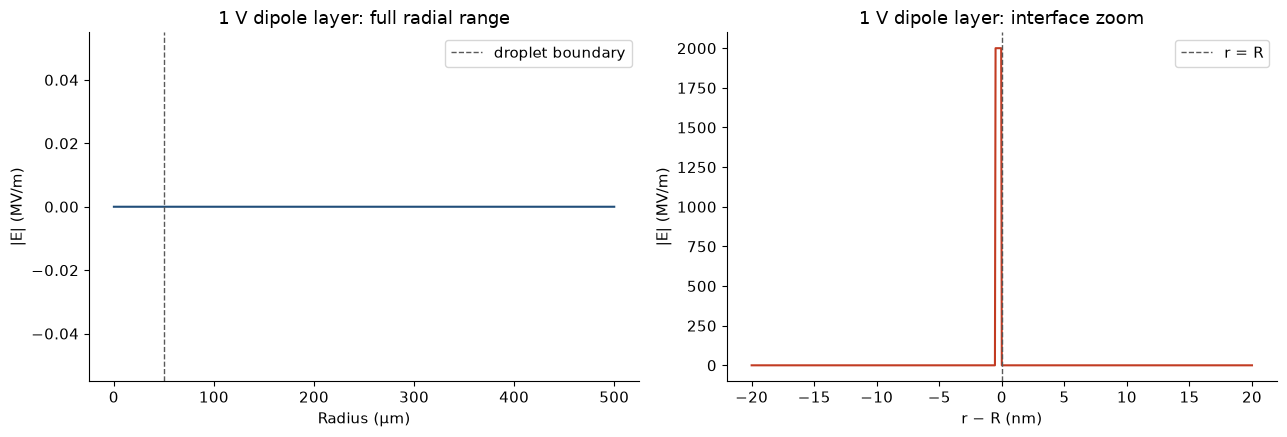

In [3]:
# 只沿 x 轴取样；球对称模型在任何方位的径向场都相同。
# 宽范围网格用于查看整体尺度，但不解析纳米厚度的界面层。
R_um = base.geometry.radius_um
r_wide_um = np.linspace(0.1, 500, 2000)
points_wide = np.column_stack((r_wide_um * 1e-6, np.zeros_like(r_wide_um), np.zeros_like(r_wide_um)))

# 在 R 和两个内侧界面附近加入 ±20 nm 的密集网格。
# 这里 1 nm = 0.001 μm，0.5 nm = 0.0005 μm。
layer_edges_um = [R_um, R_um - 1.0e-3, R_um - 0.5e-3]
local_grids_um = [np.linspace(edge - 0.02, edge + 0.02, 801) for edge in layer_edges_um]
r_zoom_um = np.unique(np.concatenate(local_grids_um))
points_zoom = np.column_stack((r_zoom_um * 1e-6, np.zeros_like(r_zoom_um), np.zeros_like(r_zoom_um)))

# 固定净 Q 的表面/体电荷，与零净 Q 的界面层形成对照。
models = {'surface': base, 'volume': base.with_updates(charge={'model': 'volume'}),
          'neutral double layer': base.with_updates(charge={'model': 'neutral_double_layer', 'q_e': 0, 'double_layer_q_e': 1e8}),
          '1 V dipole layer': base.with_updates(charge={'model': 'surface', 'q_e': 0, 'dipole_potential_v': 1.0})}

# 每个模型单独出图；两个坐标轴都保持线性，避免对数轴掩盖边界跳变。
for name, cfg in models.items():
    f = build_field(cfg)
    field_wide_mvm = abs(f.electric_field(points_wide)[:, 0]) / 1e6
    field_zoom_mvm = abs(f.electric_field(points_zoom)[:, 0]) / 1e6
    zoom = (r_zoom_um >= R_um - 0.02) & (r_zoom_um <= R_um + 0.02)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(r_wide_um, field_wide_mvm, color='#214e7a')
    axes[0].axvline(R_um, color='0.35', linestyle='--', linewidth=1, label='droplet boundary')
    axes[0].set(xlabel='Radius (μm)', ylabel='|E| (MV/m)',
                title=f'{name}: full radial range')
    axes[0].legend()

    axes[1].plot((r_zoom_um[zoom] - R_um) * 1e3, field_zoom_mvm[zoom], color='#c23b22')
    axes[1].axvline(0, color='0.35', linestyle='--', linewidth=1, label='r = R')
    axes[1].set(xlabel='r − R (nm)', ylabel='|E| (MV/m)',
                title=f'{name}: interface zoom')
    axes[1].legend()
    fig.tight_layout(); plt.show()

### 守恒离子数的球对称 Poisson–Boltzmann 解

External E for neutral PB (V/m): 0.0


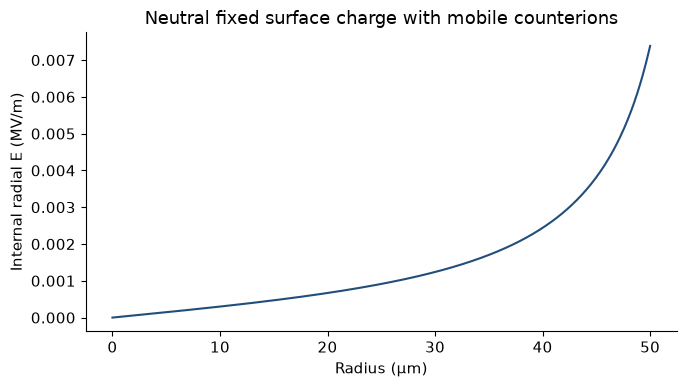

In [4]:
# -10^6 e 固定表面电荷与 +10^6 个移动反离子相抵：总净 Q=0。
from droplet_shadow.fields import poisson_boltzmann
neutral = base.with_updates(charge={'model':'poisson_boltzmann', 'q_e':0, 'surface_fixed_e':-1e6, 'ion_positive_count':1e6})
pb = poisson_boltzmann(neutral)
# 100 μm > R=50 μm；严格球对称且净电荷为零时，外场应为零。
print('External E for neutral PB (V/m):', pb.electric_field(np.array([[100e-6,0,0]]))[0,0])
fig, ax = plt.subplots()
ax.plot(pb.radii_m * 1e6, pb.field_v_m / 1e6, color='#214e7a')
ax.set(xlabel='Radius (μm)', ylabel='Internal radial E (MV/m)', title='Neutral fixed surface charge with mobile counterions')
fig.tight_layout(); plt.show()

## 实现追溯

本 Notebook 调用的构造器在 [`fields.py`](../src/droplet_shadow/fields.py)，参数约束在 [`config.py`](../src/droplet_shadow/config.py)，可执行物理不变量在 [`test_physics.py`](../tests/test_physics.py)。其中 `RadialShells._radial`、`UniformVolume._radial`和 `poisson_boltzmann` 是人工复核的主要入口。更完整的逐层审计见 `05_implementation_audit.ipynb`。

## Takeaways

每个模型现在单独显示，两个坐标轴均为线性。`volume` 模型在液滴外部应是一条平滑的 1/r² 曲线；在 r=R 处的电场跳变来自水/真空介电边界。严格中性双层和偶极层在外部没有宏观电场，但在纳米界面放大图中仍可看到局域场。穿滴电子仍可能感受到内部场与材料散射。这里的连续介质场不等于单个分子键方向的瞬时场。